# Cognifyz Data Analysis Internship

## Level 1 - Task 1

### Task:
Determine the top three most common cuisines in the dataset and calculate the percentage of restaurants serving each cuisine.

**Name:** Suraj 


In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load Dataset

df = pd.read_csv("Dataset .csv")

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.shape

(9551, 21)

In [5]:
df["Cuisines"].head(10)

0            French, Japanese, Desserts
1                              Japanese
2      Seafood, Asian, Filipino, Indian
3                       Japanese, Sushi
4                      Japanese, Korean
5                               Chinese
6                       Asian, European
7    Seafood, Filipino, Asian, European
8               European, Asian, Indian
9                              Filipino
Name: Cuisines, dtype: object

In [6]:
top_cuisines = (
    df["Cuisines"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

top_cuisines.head(3)

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

In [7]:
total_restaurants = len(df)

top3_percentage = (
    (top_cuisines.head(3) / total_restaurants) * 100
).round(2)

top3_percentage

Cuisines
North Indian    41.46
Chinese         28.64
Fast Food       20.79
Name: count, dtype: float64

In [8]:
percentage_df = pd.DataFrame({
    "Cuisine": top3_percentage.index,
    "Percentage (%)": top3_percentage.values
})

percentage_df

,Cuisine,Percentage (%)
0,North Indian,41.46
1,Chinese,28.64
2,Fast Food,20.79


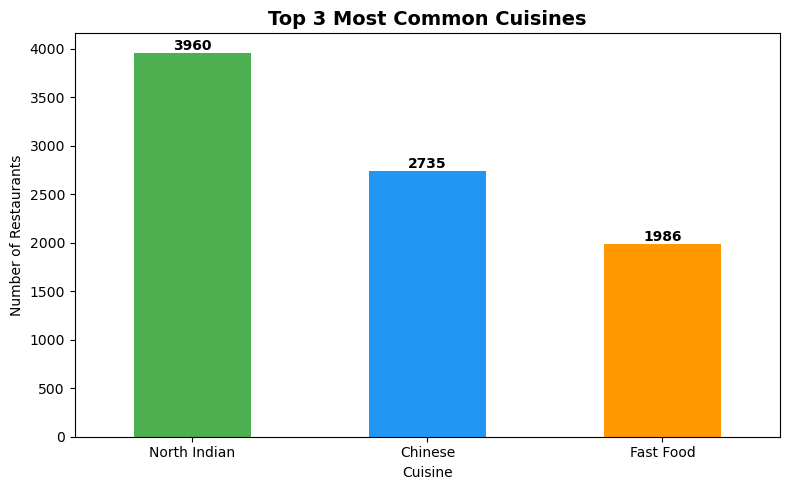

In [9]:
plt.figure(figsize=(8,5))

ax = top_cuisines.head(3).plot(
    kind="bar",
    color=["#4CAF50", "#2196F3", "#FF9800"]
)

plt.title("Top 3 Most Common Cuisines", fontsize=14, fontweight="bold")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

# Data Labels
for i in ax.patches:
    ax.annotate(
        str(int(i.get_height())),
        (i.get_x() + i.get_width()/2, i.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## Insights

- North Indian cuisine is the most common cuisine in the dataset with 3960 restaurants (41.46%).
- Chinese cuisine is the second most common cuisine with 2735 restaurants (28.64%).
- Fast Food ranks third with 1986 restaurants (20.79%).
- Since one restaurant can offer multiple cuisines, the percentages do not add up to 100%.

## Conclusion

The analysis shows that North Indian cuisine is the most popular cuisine in the dataset, followed by Chinese and Fast Food. These cuisines are offered by a large number of restaurants, indicating their high popularity.